In [11]:
from lightgbm.basic import LightGBMError
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings("ignore")

In [12]:
X, y = load_breast_cancer(return_X_y=True)

In [13]:
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [14]:
len(y)

569

In [15]:
models = {
    '决策树\n(Baseline)': DecisionTreeClassifier(random_state=42),
    '随机森林\n(Bagging)': RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    'GBDT\n(Boosting)': GradientBoostingClassifier(
        n_estimators=100, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, eval_metric='logloss', random_state=42
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100, verbose=-1, random_state=42
    )
}

In [16]:
names = []
means = []
stds = []

In [17]:
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

    names.append(name)
    means.append(scores.mean())
    stds.append(scores.std())

    print(f"{name.replace(chr(10), ' '):.<30s} {scores.mean():.4f} (±{scores.std():.4f})")

决策树 (Baseline)................ 0.9173 (±0.0242)
随机森林 (Bagging)................ 0.9561 (±0.0228)
GBDT (Boosting)............... 0.9631 (±0.0210)
XGBoost....................... 0.9736 (±0.0147)
LightGBM...................... 0.9701 (±0.0172)


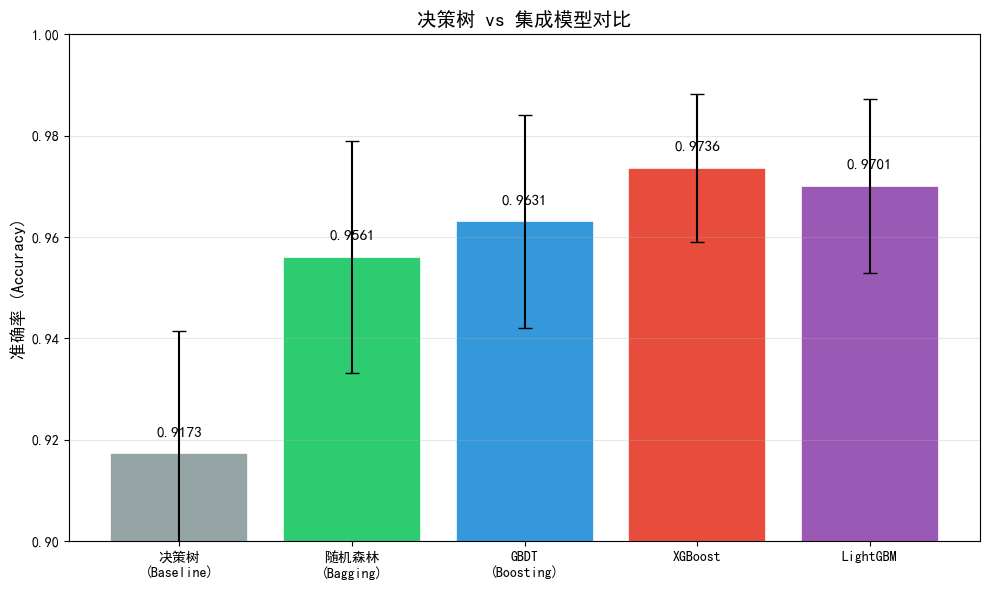


图表已保存为 ensemble_comparison.png


In [18]:
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#95a5a6', '#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

bars = ax.bar(range(len(names)), means, yerr=stds, capsize=5, color=colors, edgecolor='white', linewidth=1.2)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel('准确率 (Accuracy)', fontsize=12)
ax.set_title('决策树 vs 集成模型对比', fontsize=14, fontweight='bold')
ax.set_ylim(0.90, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ensemble_comparison.png', dpi=150, bbox_inches='tight')

plt.show()
print("\n图表已保存为 ensemble_comparison.png")

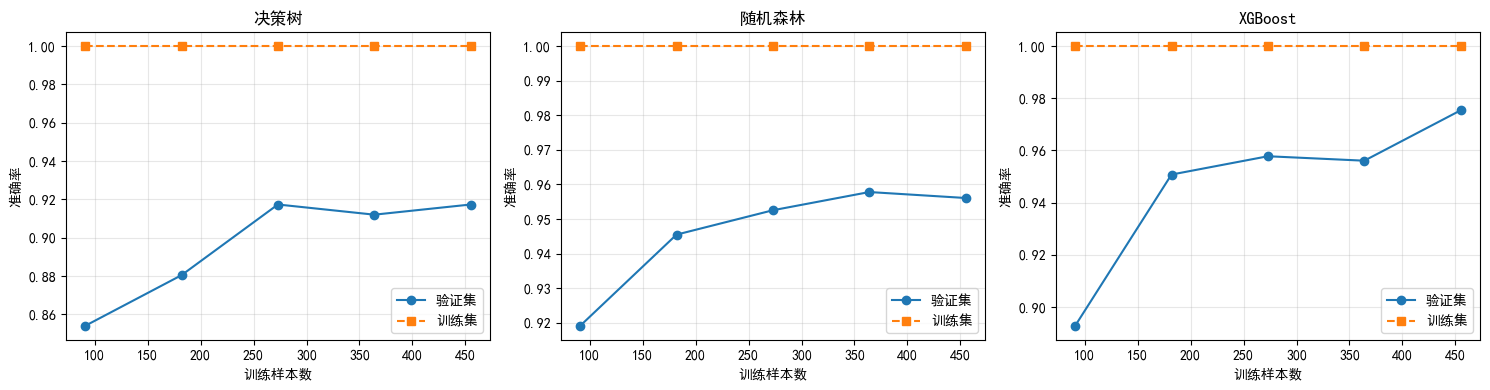

In [19]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, [
    ('决策树', DecisionTreeClassifier(random_state=42)),
    ('随机森林', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('XGBoost', XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)),
]):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.2, 1.0, 5), random_state=42
    )
    ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='验证集')
    ax.plot(train_sizes, train_scores.mean(axis=1), 's--', label='训练集')
    ax.set_title(name)
    ax.set_xlabel('训练样本数')
    ax.set_ylabel('准确率')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()